# Apply the MAC-LWP convective mask (PD LWP) or a land mask (everything), or no mask (everything), and take a weighted mean
* CAM6 PPE
* GA7.1 PPE
* E3SMv3 Nephele PPE (rerun!)
* ECHAM6-HAM PPE
* CMIP6 models

Also mask land & regrid to 1x1 for E3SMv3 - to make spatial maps 


In [1]:
import pickle
import glob
import sys
sys.path.append("/glade/work/jnug/codes/e3sm-ppe-aci/analysis/python")

import e3sm_util as util
import xarray as xr
import numpy as np
import xesmf as xe
import pandas as pd

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from global_land_mask import globe


In [2]:
file_path = "/glade/u/home/jnug/work/multi_PPE_data/"

mask_path = file_path + "masks/"
ga_path = file_path + "GA7.1/"
cam6_path = file_path + "CAM6/"
e3sm_path = "/glade/campaign/uwyo/wyom0191/ppev0/processed_reruns/"
cmip6_path = file_path + "CMIP6/"
cmip6_new_path = file_path + "CMIP6_new/" # additional data downloaded after revisions
eham_path = file_path + "ECHAM6-HAM/"

out_path = file_path + "annual_means/"


In [4]:
def mask_land_latlon(da):
    """ Mask out land (ocean only) for a data array with a regular lat-lon grid
    """
    longrid, latgrid = np.meshgrid(da.lon, da.lat)
    
    if longrid.max() > 180:
        longrid = ((longrid + 180) % 360) - 180
    mask = xr.DataArray(globe.is_ocean(latgrid, longrid), dims=["lat", "lon"])
    ocn_only = da.where(mask)
    
    return ocn_only


#### ECHAM6-HAM

In [13]:
# AOD

eh_aod_pi = xr.open_dataset(eham_path + "PI_AOD_PPE_ECHAM.nc")["TAU_2D_550nm"]

attrs = {
    "mask": "none",
    "mean": "annual mean",
    "PPE": "ECHAM6-HAM",
    "notes": "n/a"
}
ds_eh_aod_pi = xr.Dataset({"AODVIS_PI": eh_aod_pi}, attrs=attrs).rename({"ensemble": "member"})
ds_eh_aod_pi.to_netcdf(out_path + "ECHAM6-HAM_AOD_PI_annual_mean.nc")


In [5]:
eham_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_eham_ppe.nc")["clwp"]
eham_mask = xr.where(eham_mask >= 0, True, False)

eh_Nd_pi = xr.open_dataset(eham_path + "CDNC_PI.nc")
eh_Nd_pd = xr.open_dataset(eham_path + "CDNC_PD.nc")
eh_LWP_pi = xr.open_dataset(eham_path + "LWP_PPE_PI.nc")
eh_LWP_pd = xr.open_dataset(eham_path + "LWP_PPE_PD.nc")
eh_ERFaci = xr.open_dataset(eham_path + "ERF_ACI.nc")


In [10]:
weights = np.cos(np.deg2rad(eh_LWP_pd.lat))

eh_Nd_pi_avg_ocn = mask_land_latlon(eh_Nd_pi).weighted(weights).mean(dim=["lat", "lon"])["__xarray_dataarray_variable__"]
eh_Nd_pd_avg_ocn = mask_land_latlon(eh_Nd_pd).weighted(weights).mean(dim=["lat", "lon"])["__xarray_dataarray_variable__"]
eh_Nd_pi_avg = eh_Nd_pi.weighted(weights).mean(dim=["lat", "lon"])["__xarray_dataarray_variable__"]
eh_Nd_pd_avg = eh_Nd_pd.weighted(weights).mean(dim=["lat", "lon"])["__xarray_dataarray_variable__"]

eh_LWP_pd_masked_avg = eh_LWP_pd.where(eham_mask).weighted(weights).mean(dim=["lat", "lon"])["xlvi"]
eh_LWP_pi_avg_ocn = mask_land_latlon(eh_LWP_pi).weighted(weights).mean(dim=["lat", "lon"])["xlvi"]
eh_LWP_pd_avg_ocn = mask_land_latlon(eh_LWP_pd).weighted(weights).mean(dim=["lat", "lon"])["xlvi"]
eh_LWP_pi_avg = eh_LWP_pi.weighted(weights).mean(dim=["lat", "lon"])["xlvi"]
eh_LWP_pd_avg = eh_LWP_pd.weighted(weights).mean(dim=["lat", "lon"])["xlvi"]

eh_ERFaci_avg_ocn = mask_land_latlon(eh_ERFaci).weighted(weights).mean(dim=["lat", "lon"])["__xarray_dataarray_variable__"]
eh_ERFaci_avg = eh_ERFaci.weighted(weights).mean(dim=["lat", "lon"])["__xarray_dataarray_variable__"]


In [11]:
# note the conv mask
eh_LWP_pd_masked_avg.attrs["mask"] = "MAC-LWP convective mask (also masks land)"


In [12]:
eh_delta_Nd_avg = eh_Nd_pd_avg - eh_Nd_pi_avg
eh_delta_LWP_avg = eh_LWP_pd_avg - eh_LWP_pi_avg

eh_delta_Nd_avg_ocn = eh_Nd_pd_avg_ocn - eh_Nd_pi_avg_ocn
eh_delta_LWP_avg_ocn = eh_LWP_pd_avg_ocn - eh_LWP_pi_avg_ocn


In [14]:
data_dict = {
    "Nd_pd": eh_Nd_pd_avg,
    "Nd_pi": eh_Nd_pi_avg,
    "LWP_pd": eh_LWP_pd_avg,
    "LWP_pi": eh_LWP_pi_avg,
    "delta_Nd": eh_delta_Nd_avg,
    "delta_LWP": eh_delta_LWP_avg,
    "ERFaci": eh_ERFaci_avg,
    "Nd_pd_ocn": eh_Nd_pd_avg_ocn,
    "Nd_pi_ocn": eh_Nd_pi_avg_ocn,
    "LWP_pd_ocn": eh_LWP_pd_avg_ocn,
    "LWP_pd_masked": eh_LWP_pd_masked_avg,
    "LWP_pi_ocn": eh_LWP_pi_avg_ocn,
    "delta_Nd_ocn": eh_delta_Nd_avg_ocn,
    "delta_LWP_ocn": eh_delta_LWP_avg_ocn,
    "ERFaci_ocn": eh_ERFaci_avg_ocn
}
attrs = {
    "mask": "land masked out if var name has \'_ocn\'",
    "mean": "weighted global mean",
    "PPE": "ECHAM6-HAM",
    "notes": "n/a"
}
ds_eh = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_eh = ds_eh.rename({"ensemble": "member"})

ds_eh.to_netcdf(out_path + "ECHAM6-HAM_data_annual_means.nc")


##### Average over time only for spatial plots

In [6]:
# already are time averages
eh_Nd_pi_tavg = eh_Nd_pi["__xarray_dataarray_variable__"]
eh_Nd_pd_tavg = eh_Nd_pd["__xarray_dataarray_variable__"]

eh_LWP_pi_tavg = eh_LWP_pi["xlvi"]
eh_LWP_pd_tavg = eh_LWP_pd["xlvi"]

eh_ERFaci_tavg = eh_ERFaci["__xarray_dataarray_variable__"]
eh_delta_Nd_tavg = eh_Nd_pd_tavg - eh_Nd_pi_tavg
eh_delta_LWP_tavg = eh_LWP_pd_tavg - eh_LWP_pi_tavg


In [7]:
# time average dataset

data_dict = {
    "Nd_pd": eh_Nd_pd_tavg,
    "Nd_pi": eh_Nd_pi_tavg,
    "LWP_pd": eh_LWP_pd_tavg,
    "LWP_pi": eh_LWP_pi_tavg,
    "delta_Nd": eh_delta_Nd_tavg,
    "delta_LWP": eh_delta_LWP_tavg,
    "ERFaci": eh_ERFaci_tavg,
}

attrs = {
    "mask": "none",
    "mean": "lat-lon, time means",
    "PPE": "ECHAM6-HAM",
    "notes": "n/a"
}
ds_to_rg = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_to_rg = ds_to_rg.rename({"ensemble": "member"})
ds_to_rg.to_netcdf(out_path + "ECHAM6-HAM_data_time_avg.nc")


#### CAM6

In [30]:
# AOD

cam6_aod_pi = xr.open_dataset(cam6_path + "CAM6_PI_AOD.nc")["AODVIS"]

# get only the "good" runs (no runaway icing in tropics) - from Ci's paper
data = np.load("/glade/u/home/jnug/work/multi_PPE_data/cam6_good_ensn/ERFaci_G_sel.npz")
cam6_good_ensn = [str(x).zfill(3) for x in data["runs"]]

cam6_aod_pi = cam6_aod_pi.sel(member=cam6_good_ensn).mean(dim="time")
attrs = {
    "mask": "none",
    "mean": "annual mean",
    "PPE": "CAM6",
    "notes": "ens members with runaway tropics icing dropped"
}
ds_cam6_aod_pi = xr.Dataset({"AODVIS_PI": cam6_aod_pi}, attrs=attrs)
ds_cam6_aod_pi.to_netcdf(out_path + "CAM6_AOD_PI_annual_mean.nc")


In [11]:
cam6_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_cam6_ppe.nc")["clwp"]
cam6_mask = xr.where(cam6_mask >= 0, True, False)

# get only the "good" runs (no runaway icing in tropics) - from Ci's paper
data = np.load("/glade/u/home/jnug/work/multi_PPE_data/cam6_good_ensn/ERFaci_G_sel.npz")
cam6_good_ensn = [str(x).zfill(3) for x in data["runs"]]

ds_pd_cam6 = xr.open_dataset(cam6_path + "CAM6_PD_vars.nc").sel(member=cam6_good_ensn)
ds_pi_cam6 = xr.open_dataset(cam6_path + "CAM6_PI_vars.nc").sel(member=cam6_good_ensn)


In [16]:
weights = np.cos(np.deg2rad(ds_pd_cam6.lat))

cam6_LWP_pd_masked_avg = ds_pd_cam6["LWP"].where(cam6_mask).weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_LWP_pd_avg_ocn = mask_land_latlon(ds_pd_cam6["LWP"]).weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_LWP_pi_avg_ocn = mask_land_latlon(ds_pi_cam6["LWP"]).weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_LWP_pd_avg = ds_pd_cam6["LWP"].weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_LWP_pi_avg = ds_pi_cam6["LWP"].weighted(weights).mean(dim=["time", "lat", "lon"])

cam6_Nd_pd_avg_ocn = mask_land_latlon(ds_pd_cam6["Nd"]).weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_Nd_pi_avg_ocn = mask_land_latlon(ds_pi_cam6["Nd"]).weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_Nd_pd_avg = ds_pd_cam6["Nd"].weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_Nd_pi_avg = ds_pi_cam6["Nd"].weighted(weights).mean(dim=["time", "lat", "lon"])

cam6_SWCRE_pd = ds_pd_cam6["SWCRE"]
cam6_SWCRE_pi = ds_pi_cam6["SWCRE"]
cam6_ERFaci = cam6_SWCRE_pd - cam6_SWCRE_pi
cam6_ERFaci_avg_ocn = mask_land_latlon(cam6_ERFaci).weighted(weights).mean(dim=["time", "lat", "lon"])
cam6_ERFaci_avg = cam6_ERFaci.weighted(weights).mean(dim=["time", "lat", "lon"])


In [17]:
cam6_delta_Nd_avg = cam6_Nd_pd_avg - cam6_Nd_pi_avg
cam6_delta_LWP_avg = cam6_LWP_pd_avg - cam6_LWP_pi_avg

cam6_delta_Nd_avg_ocn = cam6_Nd_pd_avg_ocn - cam6_Nd_pi_avg_ocn
cam6_delta_LWP_avg_ocn = cam6_LWP_pd_avg_ocn - cam6_LWP_pi_avg_ocn


In [19]:
# LWP kg/m2 --> g/m2; Nd #/m3 --> #/cm3
data_dict = {
    "Nd_pd": cam6_Nd_pd_avg/1e6,
    "Nd_pi": cam6_Nd_pi_avg/1e6,
    "LWP_pd": cam6_LWP_pd_avg*1000.,
    "LWP_pi": cam6_LWP_pi_avg*1000.,
    "delta_Nd": cam6_delta_Nd_avg/1e6,
    "delta_LWP": cam6_delta_LWP_avg*1000.,
    "ERFaci": cam6_ERFaci_avg,
    "Nd_pd_ocn": cam6_Nd_pd_avg_ocn/1e6,
    "Nd_pi_ocn": cam6_Nd_pi_avg_ocn/1e6,
    "LWP_pd_ocn": cam6_LWP_pd_avg_ocn*1000.,
    "LWP_pd_masked": cam6_LWP_pd_masked_avg*1000.,
    "LWP_pi_ocn": cam6_LWP_pi_avg_ocn*1000.,
    "delta_Nd_ocn": cam6_delta_Nd_avg_ocn/1e6,
    "delta_LWP_ocn": cam6_delta_LWP_avg_ocn*1000.,
    "ERFaci_ocn": cam6_ERFaci_avg_ocn
}
attrs = {
    "mask": "land masked out if var name has \'_ocn\'",
    "mean": "weighted global mean",
    "PPE": "CAM6",
    "notes": "ens members with runaway tropics icing dropped"
}
ds_cam6 = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_cam6.to_netcdf(out_path + "CAM6_data_annual_means.nc")


##### Average over time only for spatial plots

In [12]:
cam6_LWP_pd_tavg = ds_pd_cam6["LWP"].mean(dim=["time"])
cam6_LWP_pi_tavg = ds_pi_cam6["LWP"].mean(dim=["time"])

cam6_Nd_pd_tavg = ds_pd_cam6["Nd"].mean(dim=["time"])
cam6_Nd_pi_tavg = ds_pi_cam6["Nd"].mean(dim=["time"])

cam6_SWCRE_pd = ds_pd_cam6["SWCRE"]
cam6_SWCRE_pi = ds_pi_cam6["SWCRE"]
cam6_ERFaci = cam6_SWCRE_pd - cam6_SWCRE_pi
cam6_ERFaci_tavg = cam6_ERFaci.mean(dim=["time"])

cam6_delta_Nd_tavg = cam6_Nd_pd_tavg - cam6_Nd_pi_tavg
cam6_delta_LWP_tavg = cam6_LWP_pd_tavg - cam6_LWP_pi_tavg


In [13]:
# time average dataset

data_dict = {
    "Nd_pd": cam6_Nd_pd_tavg/1e6,
    "Nd_pi": cam6_Nd_pi_tavg/1e6,
    "LWP_pd": cam6_LWP_pd_tavg*1000.,
    "LWP_pi": cam6_LWP_pi_tavg*1000.,
    "delta_Nd": cam6_delta_Nd_tavg/1e6,
    "delta_LWP": cam6_delta_LWP_tavg*1000.,
    "ERFaci": cam6_ERFaci_tavg,
}

attrs = {
    "mask": "none",
    "mean": "lat-lon, time means",
    "PPE": "CAM6",
    "notes": "ens members with runaway tropics icing dropped"
}
ds_to_rg = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_to_rg.to_netcdf(out_path + "CAM6_data_time_avg.nc")


#### GA 7.1

In [20]:
# AOD

ga_aod_pi = xr.open_dataset(ga_path + "annual_mean_AOD_550_PI.nc")["AOD550nm"]

# from Leighton's spreadsheet - indices of negative ∆Nd
ga_to_drop = [3, 42, 49, 83, 120, 127, 155, 179, 212, 214]
ga_to_keep = [x for x in ga_aod_pi.ppe_index.values if x not in ga_to_drop]


ga_aod_pi = ga_aod_pi.sel(ppe_index=ga_to_keep).rename({"ppe_index": "member"})
attrs = {
    "mask": "none",
    "mean": "annual mean",
    "PPE": "GA7.1",
    "notes": "neg Nd ens members dropped - by LR's indices"
}
ds_ga_aod_pi = xr.Dataset(data_vars={"AODVIS_PI": ga_aod_pi}, attrs=attrs)
ds_ga_aod_pi.to_netcdf(out_path + "GA7.1_AOD_PI_annual_mean.nc")


In [14]:
ga_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_ga71_ppe.nc")["clwp"]
ga_mask = xr.where(ga_mask >=0, True, False)

ga_Nd_pi = xr.open_dataset(ga_path + "annual_mean_Nd_PI.nc")
ga_Nd_pd = xr.open_dataset(ga_path + "annual_mean_Nd_PD.nc")
ga_LWP_pi = xr.open_dataset(ga_path + "annual_mean_LWP_PI.nc")
ga_LWP_pd = xr.open_dataset(ga_path + "annual_mean_LWP_PD.nc")
ga_ERFaci = xr.open_dataset(ga_path + "annual_mean_ERFaci.nc")


In [21]:
weights = np.cos(np.deg2rad(ga_LWP_pd.lat))

ga_Nd_pi_avg_ocn = mask_land_latlon(ga_Nd_pi).weighted(weights).mean(dim=["lat", "lon"])
ga_Nd_pd_avg_ocn = mask_land_latlon(ga_Nd_pd).weighted(weights).mean(dim=["lat", "lon"])
ga_Nd_pi_avg = ga_Nd_pi.weighted(weights).mean(dim=["lat", "lon"])
ga_Nd_pd_avg = ga_Nd_pd.weighted(weights).mean(dim=["lat", "lon"])

ga_LWP_pd_masked_avg = ga_LWP_pd.where(ga_mask).weighted(weights).mean(dim=["lat", "lon"])
ga_LWP_pi_avg_ocn = mask_land_latlon(ga_LWP_pi).weighted(weights).mean(dim=["lat", "lon"])
ga_LWP_pd_avg_ocn = mask_land_latlon(ga_LWP_pd).weighted(weights).mean(dim=["lat", "lon"])
ga_LWP_pi_avg = ga_LWP_pi.weighted(weights).mean(dim=["lat", "lon"])
ga_LWP_pd_avg = ga_LWP_pd.weighted(weights).mean(dim=["lat", "lon"])

ga_ERFaci_avg_ocn = mask_land_latlon(ga_ERFaci).weighted(weights).mean(dim=["lat", "lon"])
ga_ERFaci_avg = ga_ERFaci.weighted(weights).mean(dim=["lat", "lon"])


In [16]:
# from Leighton's spreadsheet - indices of negative ∆Nd
ga_to_drop = [3, 42, 49, 83, 120, 127, 155, 179, 212, 214]
ga_to_keep = [x for x in ga_Nd_pi.ppe_index.values if x not in ga_to_drop]


In [23]:
# keep only the ensemble members with ∆Nd > 0
ga_Nd_pi_avg = ga_Nd_pi_avg.sel(ppe_index=ga_to_keep)["Nd"]
ga_Nd_pd_avg = ga_Nd_pd_avg.sel(ppe_index=ga_to_keep)["Nd"]
ga_LWP_pi_avg = ga_LWP_pi_avg.sel(ppe_index=ga_to_keep)["LWP"]
ga_LWP_pd_avg = ga_LWP_pd_avg.sel(ppe_index=ga_to_keep)["LWP"]
ga_ERFaci_avg = ga_ERFaci_avg.sel(ppe_index=ga_to_keep)["ERFaci"]

ga_Nd_pi_avg_ocn = ga_Nd_pi_avg_ocn.sel(ppe_index=ga_to_keep)["Nd"]
ga_Nd_pd_avg_ocn = ga_Nd_pd_avg_ocn.sel(ppe_index=ga_to_keep)["Nd"]
ga_LWP_pi_avg_ocn = ga_LWP_pi_avg_ocn.sel(ppe_index=ga_to_keep)["LWP"]
ga_LWP_pd_avg_ocn = ga_LWP_pd_avg_ocn.sel(ppe_index=ga_to_keep)["LWP"]
ga_LWP_pd_masked_avg = ga_LWP_pd_masked_avg.sel(ppe_index=ga_to_keep)["LWP"]
ga_ERFaci_avg_ocn = ga_ERFaci_avg_ocn.sel(ppe_index=ga_to_keep)["ERFaci"]



In [24]:
# note the conv mask
ga_LWP_pd_masked_avg.attrs["mask"] = "MAC-LWP convective mask (also masks land)"


In [25]:
ga_delta_Nd_avg = ga_Nd_pd_avg - ga_Nd_pi_avg
ga_delta_LWP_avg = ga_LWP_pd_avg - ga_LWP_pi_avg

ga_delta_Nd_avg_ocn = ga_Nd_pd_avg_ocn - ga_Nd_pi_avg_ocn
ga_delta_LWP_avg_ocn = ga_LWP_pd_avg_ocn - ga_LWP_pi_avg_ocn


In [26]:
data_dict = {
    "Nd_pd": ga_Nd_pd_avg,
    "Nd_pi": ga_Nd_pi_avg,
    "LWP_pd": ga_LWP_pd_avg,
    "LWP_pi": ga_LWP_pi_avg,
    "delta_Nd": ga_delta_Nd_avg,
    "delta_LWP": ga_delta_LWP_avg,
    "ERFaci": ga_ERFaci_avg,
    "Nd_pd_ocn": ga_Nd_pd_avg_ocn,
    "Nd_pi_ocn": ga_Nd_pi_avg_ocn,
    "LWP_pd_ocn": ga_LWP_pd_avg_ocn,
    "LWP_pd_masked": ga_LWP_pd_masked_avg,
    "LWP_pi_ocn": ga_LWP_pi_avg_ocn,
    "delta_Nd_ocn": ga_delta_Nd_avg_ocn,
    "delta_LWP_ocn": ga_delta_LWP_avg_ocn,
    "ERFaci_ocn": ga_ERFaci_avg_ocn
}
attrs = {
    "mask": "land masked out if var name has \'_ocn\'",
    "mean": "weighted global mean",
    "PPE": "GA7.1",
    "notes": "neg Nd ens members dropped - by LR's indices"
}
ds_ga = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_ga = ds_ga.rename({"ppe_index": "member"})
ds_ga.to_netcdf(out_path + "GA7.1_data_annual_means.nc")


##### Average over time only for spatial plots


In [17]:
ga_Nd_pi_tavg = ga_Nd_pi.sel(ppe_index=ga_to_keep)["Nd"]
ga_Nd_pd_tavg = ga_Nd_pd.sel(ppe_index=ga_to_keep)["Nd"]
ga_LWP_pi_tavg = ga_LWP_pi.sel(ppe_index=ga_to_keep)["LWP"]
ga_LWP_pd_tavg = ga_LWP_pd.sel(ppe_index=ga_to_keep)["LWP"]
ga_ERFaci_tavg = ga_ERFaci.sel(ppe_index=ga_to_keep)["ERFaci"]
ga_delta_Nd_tavg = ga_Nd_pd_tavg - ga_Nd_pi_tavg
ga_delta_LWP_tavg = ga_LWP_pd_tavg - ga_LWP_pi_tavg


In [18]:
data_dict = {
    "Nd_pd": ga_Nd_pd_tavg,
    "Nd_pi": ga_Nd_pi_tavg,
    "LWP_pd": ga_LWP_pd_tavg,
    "LWP_pi": ga_LWP_pi_tavg,
    "delta_Nd": ga_delta_Nd_tavg,
    "delta_LWP": ga_delta_LWP_tavg,
    "ERFaci": ga_ERFaci_tavg,
}
attrs = {
    "mask": "none",
    "mean": "lat-lon, time means",
    "PPE": "GA7.1",
    "notes": "neg Nd ens members dropped - by LR's indices"
}

ds_to_rg = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_to_rg = ds_to_rg.rename({"ppe_index": "member"})
ds_to_rg.to_netcdf(out_path + "GA7.1_data_time_avg.nc")


#### E3SMv3


In [34]:
# drop first three months - Jan, Feb, Mar
no_spinup = slice("2010-04-01", None)

# monthly mean files have coordinate for first day of next month,
# so this will actually drop first 3 months (2010-05-01 files are for April 1-30)
no_spinup_m = slice("2010-05-01", None) 


In [27]:
# AOD PI (regridded to 1x1 for spatial & zonal means)

e3sm_aodvis_pi = xr.open_dataset(e3sm_path + "nephele_rerun_PI_AODVIS_0-250.nc")["AODVIS"].sel(time=no_spinup).mean(dim="time") 
attrs = {
    "mask": "none",
    "mean": "annual mean",
    "PPE": "E3SMv3",
    "notes": "months 3-27, all ens members (reruns)"
}
ds_e3sm_aod_pi = xr.Dataset({"AODVIS_PI": e3sm_aodvis_pi}, attrs=attrs)

# save time average first
ds_e3sm_aod_pi.to_netcdf(out_path + "E3SMv3_AOD_PI_annual_mean.nc")

# regrid
map_file = "/glade/campaign/uwyo/wyom0191/e3sm_map_files/map_ne30pg2_to_cmip6_180x360_nco.20200901.nc"
rg_file = out_path + "E3SMv3_AOD_PI_annual_mean_regrid1x1.nc"
! module load nco; ncremap -a fv2fv -m {map_file} -i {out_path}E3SMv3_AOD_PI_annual_mean.nc -o {rg_file}


Input #00: /glade/u/home/jnug/work/multi_PPE_data/annual_means/E3SMv3_AOD_PI_annual_mean.nc
Map/Wgt  : /glade/campaign/uwyo/wyom0191/e3sm_map_files/map_ne30pg2_to_cmip6_180x360_nco.20200901.nc
ncks: INFO Reducing user-requested thread number = 2 to maximum thread number omp_get_max_threads() allows = 1
ncks: WARNING NC_DOUBLE version of "_FillValue" attribute for AODVIS_PI is NaN and this value fails isfinite(). Therefore valid values cannot be arithmetically compared to the _FillValue, and this can lead to unpredictable results.
HINT: If arithmetic results (e.g., from regridding) fails or values seem weird, retry after first converting _FillValue to a normal number with, e.g., "ncatted -a _FillValue,AODVIS_PI,m,f,1.0e36 in.nc out.nc"


In [6]:
e3sm_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_e3sm_ppe.nc")["clwp"]
e3sm_mask = xr.where(e3sm_mask >=0, True, False)

e3sm_Nd_pi = xr.open_dataset(e3sm_path + "nephele_rerun_PI_inverted_v_vars_computed_0-250.nc")["Nd"].sel(time=no_spinup)
e3sm_Nd_pd = xr.open_dataset(e3sm_path + "nephele_rerun_PD_inverted_v_vars_computed_0-250.nc")["Nd"].sel(time=no_spinup)
e3sm_LWP_pi = xr.open_dataset(e3sm_path + "nephele_rerun_PI_inverted_v_vars_computed_0-250.nc")["LWP"].sel(time=no_spinup)
e3sm_LWP_pd = xr.open_dataset(e3sm_path + "nephele_rerun_PD_inverted_v_vars_computed_0-250.nc")["LWP"].sel(time=no_spinup)
e3sm_ERFaci = xr.open_dataset(e3sm_path + "nephele_rerun_ERFaci_0-250.nc")["ERFaci_SW"].sel(time=no_spinup_m)


##### Global means

In [7]:
e3sm_Nd_pi_avg = util.weighted_mean(e3sm_Nd_pi, dims=["ncol", "time"])
e3sm_Nd_pd_avg = util.weighted_mean(e3sm_Nd_pd, dims=["ncol", "time"])
e3sm_LWP_pi_avg = util.weighted_mean(e3sm_LWP_pi, dims=["ncol", "time"])
e3sm_LWP_pd_avg = util.weighted_mean(e3sm_LWP_pd, dims=["ncol", "time"])
e3sm_ERFaci_avg = util.weighted_mean(e3sm_ERFaci, dims=["ncol", "time"])

# since E3SM is unstructured, use its own land/ocean mask to mask out land
e3sm_Nd_pi_avg_ocn = util.weighted_mean(util.mask_land(e3sm_Nd_pi, value=0), dims=["ncol", "time"])
e3sm_Nd_pd_avg_ocn = util.weighted_mean(util.mask_land(e3sm_Nd_pd, value=0), dims=["ncol", "time"])
e3sm_LWP_pi_avg_ocn = util.weighted_mean(util.mask_land(e3sm_LWP_pi, value=0), dims=["ncol", "time"])
e3sm_LWP_pd_avg_ocn = util.weighted_mean(util.mask_land(e3sm_LWP_pd, value=0), dims=["ncol", "time"])
e3sm_ERFaci_avg_ocn = util.weighted_mean(util.mask_land(e3sm_ERFaci, value=0), dims=["ncol", "time"])


In [8]:
e3sm_LWP_pd_masked_avg = util.weighted_mean(e3sm_LWP_pd.where(e3sm_mask), dims=["ncol", "time"])


In [9]:
# note the conv mask
e3sm_LWP_pd_masked_avg.attrs["mask"] = "MAC-LWP convective mask (also masks land)"


In [10]:
e3sm_delta_Nd_avg = e3sm_Nd_pd_avg - e3sm_Nd_pi_avg
e3sm_delta_LWP_avg = e3sm_LWP_pd_avg - e3sm_LWP_pi_avg

e3sm_delta_Nd_avg_ocn = e3sm_Nd_pd_avg_ocn - e3sm_Nd_pi_avg_ocn
e3sm_delta_LWP_avg_ocn = e3sm_LWP_pd_avg_ocn - e3sm_LWP_pi_avg_ocn


In [12]:
data_dict = {
    "Nd_pd": e3sm_Nd_pd_avg,
    "Nd_pi": e3sm_Nd_pi_avg,
    "LWP_pd": e3sm_LWP_pd_avg,
    "LWP_pi": e3sm_LWP_pi_avg,
    "delta_Nd": e3sm_delta_Nd_avg,
    "delta_LWP": e3sm_delta_LWP_avg,
    "ERFaci": e3sm_ERFaci_avg,
    "Nd_pd_ocn": e3sm_Nd_pd_avg_ocn,
    "Nd_pi_ocn": e3sm_Nd_pi_avg_ocn,
    "LWP_pd_ocn": e3sm_LWP_pd_avg_ocn,
    "LWP_pd_masked": e3sm_LWP_pd_masked_avg,
    "LWP_pi_ocn": e3sm_LWP_pi_avg_ocn,
    "delta_Nd_ocn": e3sm_delta_Nd_avg_ocn,
    "delta_LWP_ocn": e3sm_delta_LWP_avg_ocn,
    "ERFaci_ocn": e3sm_ERFaci_avg_ocn
}
attrs = {
    "mask": "land masked out if var name has \'_ocn\'",
    "mean": "weighted global mean",
    "PPE": "E3SMv3 (Nephele)",
    "notes": "months 3-27, all ens members (reruns), spinup removed"
}
ds_e3sm = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_e3sm.to_netcdf(out_path + "rerun__E3SMv3_data_annual_means.nc")


##### Lat-lon files to regrid 

In [7]:
# needed to regrid via nco
map_file = "/glade/campaign/uwyo/wyom0191/e3sm_map_files/map_ne30pg2_to_cmip6_180x360_nco.20200901.nc"


In [9]:
# time average dataset
e3sm_Nd_pi_tavg = e3sm_Nd_pi.mean(dim="time")
e3sm_Nd_pd_tavg = e3sm_Nd_pd.mean(dim="time")
e3sm_LWP_pi_tavg = e3sm_LWP_pi.mean(dim="time")
e3sm_LWP_pd_tavg = e3sm_LWP_pd.mean(dim="time")
e3sm_ERFaci_tavg = e3sm_ERFaci.mean(dim="time")

e3sm_delta_Nd_tavg = e3sm_Nd_pd_tavg - e3sm_Nd_pi_tavg
e3sm_delta_LWP_tavg = e3sm_LWP_pd_tavg - e3sm_LWP_pi_tavg

data_dict = {
    "Nd_pd": e3sm_Nd_pd_tavg,
    "Nd_pi": e3sm_Nd_pi_tavg,
    "LWP_pd": e3sm_LWP_pd_tavg,
    "LWP_pi": e3sm_LWP_pi_tavg,
    "delta_Nd": e3sm_delta_Nd_tavg,
    "delta_LWP": e3sm_delta_LWP_tavg,
    "ERFaci": e3sm_ERFaci_tavg,
}

attrs = {
    "mask": "none",
    "mean": "lat-lon, time means",
    "PPE": "E3SMv3",
    "notes": "months 3-27, all ens members (reruns)"
}
ds_to_rg = xr.Dataset(data_vars=data_dict, attrs=attrs)
ds_to_rg.to_netcdf(out_path + "E3SMv3_data_time_avg.nc")


In [10]:
# regrid it

rg_file = out_path + "E3SMv3_data_regrid1x1.nc"

! module load nco; ncremap -a fv2fv -m {map_file} -i {out_path}/E3SMv3_data_time_avg.nc -o {rg_file}


Input #00: /glade/u/home/jnug/work/multi_PPE_data/annual_means//E3SMv3_data_time_avg.nc
Map/Wgt  : /glade/campaign/uwyo/wyom0191/e3sm_map_files/map_ne30pg2_to_cmip6_180x360_nco.20200901.nc
ncks: INFO Reducing user-requested thread number = 2 to maximum thread number omp_get_max_threads() allows = 1
ncks: WARNING NC_DOUBLE version of "_FillValue" attribute for ERFaci is NaN and this value fails isfinite(). Therefore valid values cannot be arithmetically compared to the _FillValue, and this can lead to unpredictable results.
HINT: If arithmetic results (e.g., from regridding) fails or values seem weird, retry after first converting _FillValue to a normal number with, e.g., "ncatted -a _FillValue,ERFaci,m,f,1.0e36 in.nc out.nc"
ncks: WARNING NC_DOUBLE version of "_FillValue" attribute for LWP_pd is NaN and this value fails isfinite(). Therefore valid values cannot be arithmetically compared to the _FillValue, and this can lead to unpredictable results.
HINT: If arithmetic results (e.g., f

In [11]:
# check it
ds_rg = xr.open_dataset(rg_file)

In [12]:
ds_rg

<xarray.Dataset> Size: 456MB
Dimensions:    (lat: 180, nbnd: 2, lon: 360, member: 251)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * member     (member) int64 2kB 0 1 2 3 4 5 6 ... 244 245 246 247 248 249 250
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds   (lat, nbnd) float64 3kB ...
    lon_bnds   (lon, nbnd) float64 6kB ...
    gw         (lat) float64 1kB ...
    area       (lat, lon) float64 518kB ...
    ERFaci     (member, lat, lon) float32 65MB ...
    LWP_pd     (member, lat, lon) float32 65MB ...
    LWP_pi     (member, lat, lon) float32 65MB ...
    Nd_pd      (member, lat, lon) float32 65MB ...
    Nd_pi      (member, lat, lon) float32 65MB ...
    delta_LWP  (member, lat, lon) float32 65MB ...
    delta_Nd   (member, lat, lon) float32 65MB ...
Attributes:
    mask:            none
    mean:            lat-lon, time means
    PPE:             E3SMv3
    notes:           months 3-27, all ens members (reruns)
    history:         Mon Feb 16 17:21:47 2026: ncks -O -t 2 --no_tmp_fl --hdr...
    remap_script:    ncremap
    remap_hostname:  crhtc91
    remap_version:   5.3.1
    NCO:             netCDF Operators version 5.3.1 (Homepage = http://nco.sf...
    title:           Regridded version of E3SMv3_data_time_avg.nc
    map_file:        /glade/campaign/uwyo/wyom0191/e3sm_map_files/map_ne30pg2...
    input_file:      /glade/u/home/jnug/work/multi_PPE_data/annual_means//E3S...

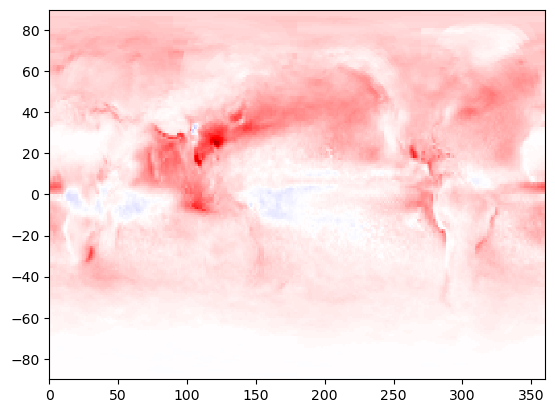

In [13]:
plt.pcolormesh(ds_rg.lon, ds_rg.lat, ds_rg["delta_LWP"].mean(dim="member"), vmin=-11, vmax=11, cmap="seismic")
plt.show()


#### CMIP6

In [5]:
def regrid_mask_cmip6(target_da, method="bilinear"):
    """ 
    Regrid the CAM6-gridded MAC-LWP mask onto a CMIP6 grid (from target_da).
    Lons must be -180 to 180 for this to work.
    """
    cam6_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_cam6_ppe.nc")["clwp"]
    mask = fix_lons(cam6_mask)
    ds_out = xr.Dataset({"lat": (["lat"], target_da.lat.values), "lon": (["lon"], target_da.lon.values)})
    regridder = xe.Regridder(mask, ds_out, method=method)
    mask_rg = regridder(mask)
    mask_rg = xr.where(mask_rg >= 0, True, False)
    
    return mask_rg


In [6]:
def fix_lons(da):
    """ Helper function; lons 0-360 --> -180 to 180
    """
    return da.assign_coords({"lon": ((da.lon + 180) % 360) - 180}).sortby("lon")
    

##### All other available models with the right data
i.e., added for revisions

In [7]:
# # get the list of ALL models from file names that has both the PI & PD scenarios

# has_pd = list(set([file.split("_")[5] for file in list(sorted(glob.glob(cmip6_new_path + "*piClim-aer*.nc")))]))
# has_pi = list(set([file.split("_")[5] for file in list(sorted(glob.glob(cmip6_new_path + "*piClim-control*.nc")))]))
# has_both = [x for x in has_pd if x in has_pi]

# ---> hardcode the list; all models that have all vars
cmip6_new_models = [
     'MRI-ESM2-0',
     # 'GFDL-ESM4', # no clivi for piClim-control
     'GISS-E2-1-G',
     'MPI-ESM-1-2-HAM',
     # 'UKESM1-0-LL', # oops, already had this one
     'BCC-ESM1',
     # 'ACCESS-CM2', # no clwvi
     'NorESM2-LM',
     'NorESM2-MM'
]

In [10]:
cmip6_new_dict = {}
cam6_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_cam6_ppe.nc")["clwp"]

for model in cmip6_new_models:
    # this one has an additional file for 1980 that we don't need
    if model == "MRI-ESM2-0":
        time_str = "185001-187912"
    else:
        time_str = ""
        
    # if multiple variants/iterations, just use the first 
    if model == "UKESM1-0-LL":
        rz_str = "r1i1p1f2"
    else:
        rz_str = "r1i1p1f1"
        
    print(model)

    # these two have the 30-year period broken into multiple files;load all first
    if model == "NorESM2-LM" or model == "MPI-ESM-1-2-HAM" or model == "NorESM2-MM":
        clwvi_pi = xr.concat([xr.open_dataset(file)["clwvi"] for file in glob.glob(cmip6_new_path + f"clwvi*{model}*piClim-control*{rz_str}*{time_str}*")], dim="time").sortby("time")
        clivi_pi = xr.concat([xr.open_dataset(file)["clivi"] for file in glob.glob(cmip6_new_path + f"clivi*{model}*piClim-control*{rz_str}*{time_str}*")], dim="time").sortby("time")
        clwvi_pd = xr.concat([xr.open_dataset(file)["clwvi"] for file in glob.glob(cmip6_new_path + f"clwvi*{model}*piClim-aer*{rz_str}*{time_str}*")], dim="time").sortby("time")
        clivi_pd = xr.concat([xr.open_dataset(file)["clivi"] for file in glob.glob(cmip6_new_path + f"clivi*{model}*piClim-aer*{rz_str}*{time_str}*")], dim="time").sortby("time")
        rsut_pi = xr.concat([xr.open_dataset(file)["rsut"] for file in glob.glob(cmip6_new_path + f"rsut_*{model}*piClim-control*{rz_str}*{time_str}*")], dim="time").sortby("time")
        rsutcs_pi = xr.concat([xr.open_dataset(file)["rsutcs"] for file in glob.glob(cmip6_new_path + f"rsutcs_*{model}*piClim-control*{rz_str}*{time_str}*")], dim="time").sortby("time")
        rsut_pd = xr.concat([xr.open_dataset(file)["rsut"] for file in glob.glob(cmip6_new_path + f"rsut_*{model}*piClim-aer*{rz_str}*{time_str}*")], dim="time").sortby("time")
        rsutcs_pd = xr.concat([xr.open_dataset(file)["rsutcs"] for file in glob.glob(cmip6_new_path + f"rsutcs_*{model}*piClim-aer*{rz_str}*{time_str}*")], dim="time").sortby("time")

    # the other ones only have 1 file per var
    else:
        clwvi_pi = xr.open_dataset(glob.glob(cmip6_new_path + f"clwvi*{model}*piClim-control*{rz_str}*{time_str}*")[0])["clwvi"]
        clivi_pi = xr.open_dataset(glob.glob(cmip6_new_path + f"clivi*{model}*piClim-control*{rz_str}*{time_str}*")[0])["clivi"]
        clwvi_pd = xr.open_dataset(glob.glob(cmip6_new_path + f"clwvi*{model}*piClim-aer*{rz_str}*{time_str}*")[0])["clwvi"]
        clivi_pd = xr.open_dataset(glob.glob(cmip6_new_path + f"clivi*{model}*piClim-aer*{rz_str}*{time_str}*")[0])["clivi"]
        rsut_pi = xr.open_dataset(glob.glob(cmip6_new_path + f"rsut_*{model}*piClim-control*{rz_str}*{time_str}*")[0])["rsut"]
        rsutcs_pi = xr.open_dataset(glob.glob(cmip6_new_path + f"rsutcs_*{model}*piClim-control*{rz_str}*{time_str}*")[0])["rsutcs"]
        rsut_pd = xr.open_dataset(glob.glob(cmip6_new_path + f"rsut_*{model}*piClim-aer*{rz_str}*{time_str}*")[0])["rsut"]
        rsutcs_pd = xr.open_dataset(glob.glob(cmip6_new_path + f"rsutcs_*{model}*piClim-aer*{rz_str}*{time_str}*".format(model))[0])["rsutcs"]
    
    
    # LWP = clwvi - clivi
    da_lwp_pd = clwvi_pd - clivi_pd
    da_lwp_pi = clwvi_pi - clivi_pi

    # convert from kg/m2 --> g/m2 and get lons to -180/180 (not 0/360)
    # (needed for the xESMF regridder)
    da_lwp_pi = fix_lons(da_lwp_pi*1000.)
    da_lwp_pd = fix_lons(da_lwp_pd*1000.)
    delta_lwp = da_lwp_pd - da_lwp_pi

    # use conservative bc that's what was used to regrid PPE masks
    mask = regrid_mask_cmip6(da_lwp_pi, method="conservative")

    # SWCRE = rsutcs - rsut
    # ERFaci = SWCRE(PD) - SWCRE(PI)
    swcre_pi = rsutcs_pi - rsut_pi
    swcre_pd = rsutcs_pd - rsut_pd
    erfaci = swcre_pd - swcre_pi
    
    # mask out conv regions & take mean
    weights = np.cos(np.deg2rad(da_lwp_pi.lat))
    LWP_pi_avg = da_lwp_pi.weighted(weights).mean(dim=["lat", "lon", "time"])
    LWP_pd_avg = da_lwp_pd.weighted(weights).mean(dim=["lat", "lon", "time"])
    delta_LWP_avg = delta_lwp.weighted(weights).mean(dim=["lat", "lon", "time"])
    erfaci_avg = erfaci.weighted(weights).mean(dim=["lat", "lon", "time"])

    LWP_pi_avg_ocn = mask_land_latlon(da_lwp_pi).weighted(weights).mean(dim=["lat", "lon", "time"])
    LWP_pd_avg_ocn = mask_land_latlon(da_lwp_pd).weighted(weights).mean(dim=["lat", "lon", "time"])
    LWP_pd_masked_avg = da_lwp_pd.where(mask).weighted(weights).mean(dim=["lat", "lon", "time"]) # only apply the mask to PD LWP
    delta_LWP_avg_ocn = mask_land_latlon(delta_lwp).weighted(weights).mean(dim=["lat", "lon", "time"])
    erfaci_avg_ocn = mask_land_latlon(erfaci).weighted(weights).mean(dim=["lat", "lon", "time"])

    # get the ln LWP to make things easier later
    dlnLWP_avg = np.log(LWP_pd_avg) - np.log(LWP_pi_avg)
    dlnLWP_avg_ocn = np.log(LWP_pd_avg_ocn) - np.log(LWP_pi_avg_ocn)

    model_dict = {
        "LWP_pi": LWP_pi_avg.values,
        "LWP_pd": LWP_pd_avg.values,
        "delta_LWP": delta_LWP_avg.values,
        "delta_lnLWP": dlnLWP_avg.values,
        "ERFaci": erfaci_avg.values,
        "LWP_pi_ocn": LWP_pi_avg_ocn.values,
        "LWP_pd_ocn": LWP_pd_avg_ocn.values,
        "LWP_pd_masked": LWP_pd_masked_avg.values,
        "delta_LWP_ocn": delta_LWP_avg_ocn.values,
        "delta_lnLWP_ocn": dlnLWP_avg_ocn.values,
        "ERFaci_ocn": erfaci_avg_ocn.values
    }

    # convert to floats - workaround for numpy dependency issue with pickle
    model_dict = dict(zip(list(model_dict.keys()), [float(x) for x in list(model_dict.values())]))

    cmip6_new_dict[model] = model_dict
    

MRI-ESM2-0


/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


GISS-E2-1-G


/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


MPI-ESM-1-2-HAM


...

/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NorESM2-LM


/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


NorESM2-MM


/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/xesmf_env/lib/python3.14/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


In [11]:
with open(out_path + "CMIP6_new_data_annual_means.pickle", "wb") as handle:
    pickle.dump(cmip6_new_dict, handle)
    

##### Models from Ci's data (Song et al., 2024)

In [17]:
cmip6_model_list = [
    "CanESM5",
    "CESM2",
    "CNRM-CM6-1",
    "CNRM-ESM2-1",
    "GFDL-CM4",
    "HadGEM3-GC31-LL",
    "IPSL-CM6A-LR",
    "MIROC6",
    "UKESM1-0-LL"
]


In [36]:
%%time

cmip6_dict = {}
cam6_mask = xr.open_dataset(mask_path + "mac-lwp_mask_for_cam6_ppe.nc")["clwp"]

for model in cmip6_model_list:
    # LWP = clwvi - clivi
    clwvi_pi = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-control*clwvi_*".format(model))[0])["clwvi"]
    clivi_pi = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-control*clivi_*".format(model))[0])["clivi"]
    clwvi_pd = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-aer*clwvi_*".format(model))[0])["clwvi"]
    clivi_pd = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-aer*clivi_*".format(model))[0])["clivi"]
    
    if model in ["MIROC6", "IPSL-CM6A-LR", "CanESM5"]:
        da_lwp_pd = clwvi_pd
        da_lwp_pi = clwvi_pi
    else:
        da_lwp_pd = clwvi_pd - clivi_pd
        da_lwp_pi = clwvi_pi - clivi_pi

    # convert from kg/m2 --> g/m2 and get lons to -180/180 (not 0/360)
    # (needed for the xESMF regridder)
    da_lwp_pi = fix_lons(da_lwp_pi*1000.)
    da_lwp_pd = fix_lons(da_lwp_pd*1000.)
    delta_lwp = da_lwp_pd - da_lwp_pi

    # use conservative bc that's what was used to regrid PPE masks
    mask = regrid_mask_cmip6(da_lwp_pi, method="conservative")

    # SWCRE = rsutcs - rsut
    rsut_pi = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-control*rsut_*".format(model))[0])["rsut"]
    rsutcs_pi = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-control*rsutcs_*".format(model))[0])["rsutcs"]
    swcre_pi = rsutcs_pi - rsut_pi
    
    rsut_pd = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-aer*rsut_*".format(model))[0])["rsut"]
    rsutcs_pd = xr.open_dataset(glob.glob(cmip6_path + "*{}*piClim-aer*rsutcs_*".format(model))[0])["rsutcs"]
    swcre_pd = rsutcs_pd - rsut_pd

    # ERFaci = SWCRE(PD) - SWCRE(PI)
    erfaci = swcre_pd - swcre_pi
    
    # mask out conv regions & take mean
    weights = np.cos(np.deg2rad(da_lwp_pi.lat))
    LWP_pi_avg = da_lwp_pi.weighted(weights).mean(dim=["lat", "lon", "time"])
    LWP_pd_avg = da_lwp_pd.weighted(weights).mean(dim=["lat", "lon", "time"])
    delta_LWP_avg = delta_lwp.weighted(weights).mean(dim=["lat", "lon", "time"])
    erfaci_avg = erfaci.weighted(weights).mean(dim=["lat", "lon", "time"])

    LWP_pi_avg_ocn = mask_land_latlon(da_lwp_pi).weighted(weights).mean(dim=["lat", "lon", "time"])
    LWP_pd_avg_ocn = mask_land_latlon(da_lwp_pd).weighted(weights).mean(dim=["lat", "lon", "time"])
    LWP_pd_masked_avg = da_lwp_pd.where(mask).weighted(weights).mean(dim=["lat", "lon", "time"]) # only apply the mask to PD LWP
    delta_LWP_avg_ocn = mask_land_latlon(delta_lwp).weighted(weights).mean(dim=["lat", "lon", "time"])
    erfaci_avg_ocn = mask_land_latlon(erfaci).weighted(weights).mean(dim=["lat", "lon", "time"])

    # get the ln LWP to make things easier later
    dlnLWP_avg = np.log(LWP_pd_avg) - np.log(LWP_pi_avg)
    dlnLWP_avg_ocn = np.log(LWP_pd_avg_ocn) - np.log(LWP_pi_avg_ocn)

    model_dict = {
        "LWP_pi": LWP_pi_avg.values,
        "LWP_pd": LWP_pd_avg.values,
        "delta_LWP": delta_LWP_avg.values,
        "delta_lnLWP": dlnLWP_avg.values,
        "ERFaci": erfaci_avg.values,
        "LWP_pi_ocn": LWP_pi_avg_ocn.values,
        "LWP_pd_ocn": LWP_pd_avg_ocn.values,
        "LWP_pd_masked": LWP_pd_masked_avg.values,
        "delta_LWP_ocn": delta_LWP_avg_ocn.values,
        "delta_lnLWP_ocn": dlnLWP_avg_ocn.values,
        "ERFaci_ocn": erfaci_avg_ocn.values
    }

    cmip6_dict[model] = model_dict
    

/glade/work/jnug/conda-envs/ppe/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/ppe/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/glade/work/jnug/conda-envs/ppe/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/jnug/conda-envs/ppe/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/glade/work/jnug/conda-envs/ppe/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


CPU times: user 29.8 s, sys: 2.97 s, total: 32.8 s
Wall time: 55 s


In [37]:
with open(out_path + "CMIP6_data_annual_means.pickle", "wb") as handle:
    pickle.dump(cmip6_dict, handle)
    

##### Quick comp

In [12]:
with open(out_path + "CMIP6_new_data_annual_means.pickle", "rb") as handle:
    cmip6_new_dict = pickle.load(handle)
with open(out_path + "CMIP6_data_annual_means.pickle", "rb") as handle:
    cmip6_dict = pickle.load(handle)
    

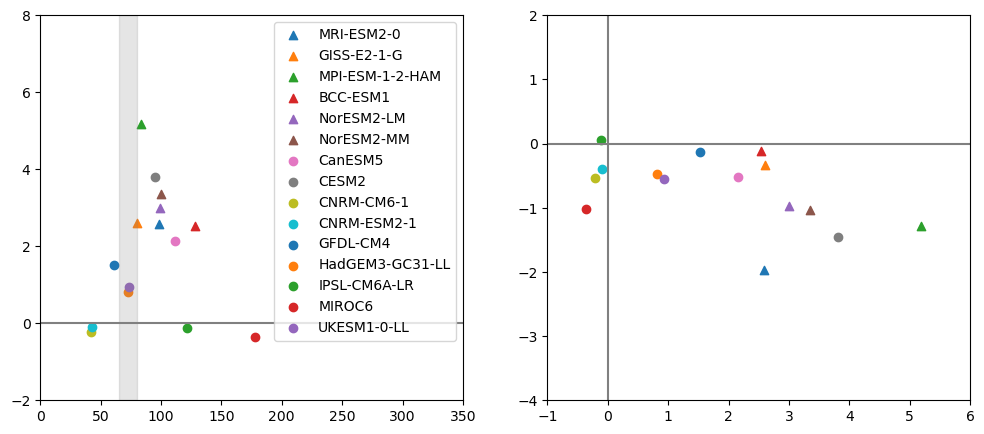

In [13]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5))

for model, mdict in cmip6_new_dict.items():
    ax1.scatter(mdict["LWP_pd_masked"], mdict["delta_LWP"], marker="^", label=model)
    ax2.scatter(mdict["delta_LWP"], mdict["ERFaci"], marker="^", label=model)

for model, mdict in cmip6_dict.items():
    ax1.scatter(mdict["LWP_pd_masked"], mdict["delta_LWP"], marker="o", label=model)
    ax2.scatter(mdict["delta_LWP"], mdict["ERFaci"], marker="o", label=model)

# ax1.legend()
ax1.legend()

ax1.set_xlim(0, 350)
ax1.set_ylim(-2, 8)
ax1.axhline(0, color="gray")
ax1.axvspan(65, 80, color="gray", alpha=0.2)

ax2.set_xlim(-1, 6)
ax2.set_ylim(-4, 2)
ax2.axhline(0, color="gray")
ax2.axvline(0, color="gray")

plt.show()


In [14]:
old_erfaci = [cmip6_dict[key]["ERFaci"] for key in list(cmip6_dict.keys())]
new_erfaci = [cmip6_new_dict[key]["ERFaci"] for key in list(cmip6_new_dict.keys())]
erfaci_cmip6 = old_erfaci + new_erfaci
print(np.min(erfaci_cmip6), np.max(erfaci_cmip6))


-1.9695655625163608 0.057225245982408524


In [15]:
old_dlnlwp = [cmip6_dict[key]["delta_lnLWP"] for key in list(cmip6_dict.keys())]
new_dlnlwp = [cmip6_new_dict[key]["delta_lnLWP"] for key in list(cmip6_new_dict.keys())]
dlnlwp_cmip6 = old_dlnlwp + new_dlnlwp
print(np.min(dlnlwp_cmip6), np.max(dlnlwp_cmip6))


-0.0062512167474144675 0.09919335757600978


##### Save a combined dataset for convenience and find new colors/keys for plots

In [16]:
# convert to floats - workaround for numpy dependency issue with pickle
cmip6_dict_float = {}
for model, model_dict in cmip6_dict.items():
    new_dict = dict(zip(list(model_dict.keys()), [float(x) for x in list(model_dict.values())]))
    cmip6_dict_float[model] = new_dict

cmip6_dict_float


{'CanESM5': {'LWP_pi': 86.31185288224836,
  'LWP_pd': 88.45835461579264,
  'delta_LWP': 2.146501734016707,
  'delta_lnLWP': 0.024564938188542662,
  'ERFaci': -0.5145548176481125,
  'LWP_pi_ocn': 93.33713752851862,
  'LWP_pd_ocn': 95.26802981815396,
  'LWP_pd_masked': 111.2019061418325,
  'delta_LWP_ocn': 1.9308922902993508,
  'delta_lnLWP_ocn': 0.02047621261863153,
  'ERFaci_ocn': -0.49502150471244066},
 'CESM2': {'LWP_pi': 64.22567938159713,
  'LWP_pd': 68.03808580532102,
  'delta_LWP': 3.8124064237123614,
  'delta_lnLWP': 0.05766451267055306,
  'ERFaci': -1.4609552378786756,
  'LWP_pi_ocn': 69.99078060710278,
  'LWP_pd_ocn': 73.3968641847691,
  'LWP_pd_masked': 94.79911880950972,
  'delta_LWP_ocn': 3.40608357757086,
  'delta_lnLWP_ocn': 0.04751768466690098,
  'ERFaci_ocn': -1.4169455057754923},
 'CNRM-CM6-1': {'LWP_pi': 34.91985331359808,
  'LWP_pd': 34.70224261620836,
  'delta_LWP': -0.21761069736224517,
  'delta_lnLWP': -0.0062512167474144675,
  'ERFaci': -0.5296604193211025,
  'LW

In [17]:
cmip6_all_dict = cmip6_new_dict | cmip6_dict_float
print(list(cmip6_all_dict.keys()), len(list(cmip6_all_dict.keys())))

with open(out_path + "CMIP6_all_data_annual_means.pickle", "wb") as handle:
    pickle.dump(cmip6_all_dict, handle)


['MRI-ESM2-0', 'GISS-E2-1-G', 'MPI-ESM-1-2-HAM', 'BCC-ESM1', 'NorESM2-LM', 'NorESM2-MM', 'CanESM5', 'CESM2', 'CNRM-CM6-1', 'CNRM-ESM2-1', 'GFDL-CM4', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MIROC6', 'UKESM1-0-LL'] 15


In [18]:
cmip6_all_dict

{'MRI-ESM2-0': {'LWP_pi': 80.4734599430797,
  'LWP_pd': 83.05637777129816,
  'delta_LWP': 2.5829178280131924,
  'delta_lnLWP': 0.031592187550463,
  'ERFaci': -1.9695655625163608,
  'LWP_pi_ocn': 89.589248183981,
  'LWP_pd_ocn': 91.91686561404694,
  'LWP_pd_masked': 98.57531798662133,
  'delta_LWP_ocn': 2.3276174299741577,
  'delta_lnLWP_ocn': 0.02564921906130646,
  'ERFaci_ocn': -1.9097455901326927},
 'GISS-E2-1-G': {'LWP_pi': 24.996196406128874,
  'LWP_pd': 27.602794762686447,
  'delta_LWP': 2.6065983570410074,
  'delta_lnLWP': 0.09919335757600978,
  'ERFaci': -0.3338519191472909,
  'LWP_pi_ocn': 28.052391151030292,
  'LWP_pd_ocn': 28.074639430474114,
  'LWP_pd_masked': 79.77009945527931,
  'delta_LWP_ocn': 0.02224827820659493,
  'delta_lnLWP_ocn': 0.0007927830985741124,
  'ERFaci_ocn': -0.04353414932017943},
 'MPI-ESM-1-2-HAM': {'LWP_pi': 61.44144120278241,
  'LWP_pd': 66.63026152385721,
  'delta_LWP': 5.188820320828681,
  'delta_lnLWP': 0.08107430594251941,
  'ERFaci': -1.2830459166

In [9]:
import tol_colors as tc

In [19]:
with open(out_path + "CMIP6_all_data_annual_means.pickle", "rb") as handle:
    cmip6_all_dict = pickle.load(handle)
    

In [30]:
# this is tol_cset("muted") with 6 additional colors

tol_muted_exp = {
    'rose': '#CC6677',
    'indigo': '#332288',
    'sand': '#DDCC77',
    'green': '#117733',
    'cyan': '#88CCEE',
    'wine': '#882255',
    'teal': '#44AA99',
    'olive': '#999933',
    'purple': '#AA4499',
    # 'pale_grey': '#DDDDDD', # skip this one
    'sky_blue': '#6699CC', # added
    'burnt_orange': '#CC5500', # added
    'forest_brown': '#664422', # added
    'slate_blue': '#5A5AAE', # added
    'charcoal': '#777777', # added
    'gold': '#F0A202' # added
}

cmip6_colors = list(tol_muted_exp.values())
cmip6_colors


['#CC6677',
 '#332288',
 '#DDCC77',
 '#117733',
 '#88CCEE',
 '#882255',
 '#44AA99',
 '#999933',
 '#AA4499',
 '#6699CC',
 '#CC5500',
 '#664422',
 '#5A5AAE',
 '#777777',
 '#F0A202']

In [28]:
# get more markers too
cmip6_markers = ['v', 'P', '^', 'X', '>', 'h', '<', 's', '*',
                 'o', 'D', 'p', 'H', 'd', '8']


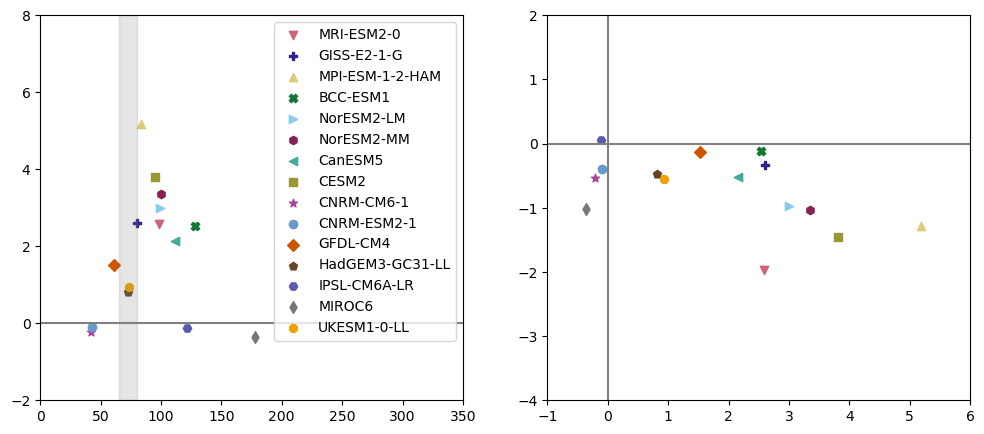

In [31]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5))


for i, model in enumerate(cmip6_all_dict.keys()):
    mdict = cmip6_all_dict[model]
    ax1.scatter(mdict["LWP_pd_masked"], mdict["delta_LWP"], label=model, 
                color=cmip6_colors[i], marker=cmip6_markers[i])
    ax2.scatter(mdict["delta_LWP"], mdict["ERFaci"], label=model, 
                color=cmip6_colors[i], marker=cmip6_markers[i])

# ax1.legend()
ax1.legend()

ax1.set_xlim(0, 350)
ax1.set_ylim(-2, 8)
ax1.axhline(0, color="gray")
ax1.axvspan(65, 80, color="gray", alpha=0.2)

ax2.set_xlim(-1, 6)
ax2.set_ylim(-4, 2)
ax2.axhline(0, color="gray")
ax2.axvline(0, color="gray")

plt.show()
